In [1]:
from libraries import *
from parameters import *
from util import *
from GetGOPrograms import *
from GenerateGRN import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
import matplotlib.patches as mpatches
from typing import Dict, List, Set
import warnings
warnings.filterwarnings('ignore')

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
go_gen = GOProgramGenerator(
        n_programs= 15,
        organism = "human", 
        total_genes = 5000,
        min_program_size = 20,
        max_program_size = 150,
        add_synthetic_program_genes= True,
        n_synthetic_per_program = [30, 80],
        synthetic_overlap_mean = 0.85,
        synthetic_overlap_std = 0.05,
        add_filler_genes =True,
        seed =42,
        data_dir ="./go_data",
        use_cached=True,
        verbose= True)

Input sequence provided is already in string format. No operation performed


go_data/go-basic.obo: fmt(1.2) rel(2026-01-23) 42,036 Terms


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

In [3]:
programs = go_gen.get_programs(k=15)
all_genes = go_gen.get_all_genes()

In [4]:
grn = GeneRegulatoryNetwork(
    programs=programs,  # From your GOProgramGenerator
    all_genes=all_genes,  # From your GOProgramGenerator
    w_activation_prob=0.7,
    v_negative_prob=0.7,
    w_mean_range=(0.6, 1.0),    # W magnitudes centered around 0.6-1.0
    w_std_range=(0.1, 0.3),     # W std varies between programs
    v_mean_range=(0.15, 0.35),  # V magnitudes smaller (0.15-0.35)
    v_std_range=(0.05, 0.15),   # V std varies between programs
    min_magnitude=0.01,          # Minimum non-zero magnitude
    seed=42,
    verbose=True
)
 


INITIALIZING PER-PROGRAM DISTRIBUTIONS
cell_cycle                      W: N(μ=0.910, σ=0.188)  V: N(μ=0.322, σ=0.120)
apoptosis                       W: N(μ=0.638, σ=0.295)  V: N(μ=0.302, σ=0.129)
immune_response                 W: N(μ=0.651, σ=0.190)  V: N(μ=0.224, σ=0.143)
dna_repair                      W: N(μ=0.858, σ=0.265)  V: N(μ=0.239, σ=0.073)
metabolism                      W: N(μ=0.822, σ=0.113)  V: N(μ=0.316, σ=0.113)
ribosome_biogenesis             W: N(μ=0.903, σ=0.171)  V: N(μ=0.344, σ=0.139)
oxidative_stress                W: N(μ=0.911, σ=0.139)  V: N(μ=0.243, σ=0.054)
autophagy                       W: N(μ=0.662, σ=0.237)  V: N(μ=0.299, σ=0.147)
cell_adhesion                   W: N(μ=0.730, σ=0.174)  V: N(μ=0.244, σ=0.069)
angiogenesis                    W: N(μ=0.652, σ=0.195)  V: N(μ=0.195, σ=0.117)
hypoxia_response                W: N(μ=0.775, σ=0.267)  V: N(μ=0.290, σ=0.081)
er_stress                       W: N(μ=0.933, σ=0.261)  V: N(μ=0.227, σ=0.079)
inflammatory

In [5]:
dist_params = grn.get_program_distributions()

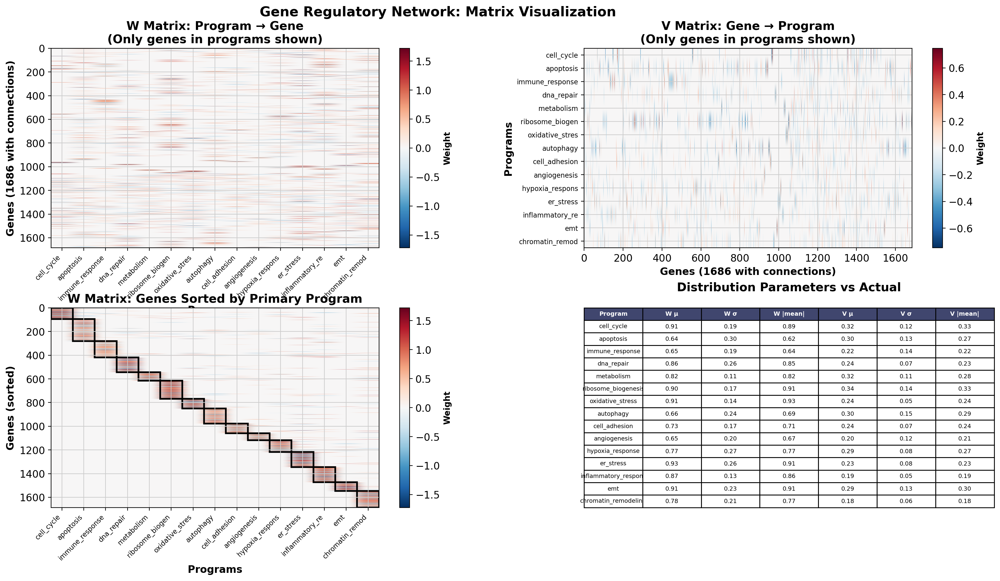

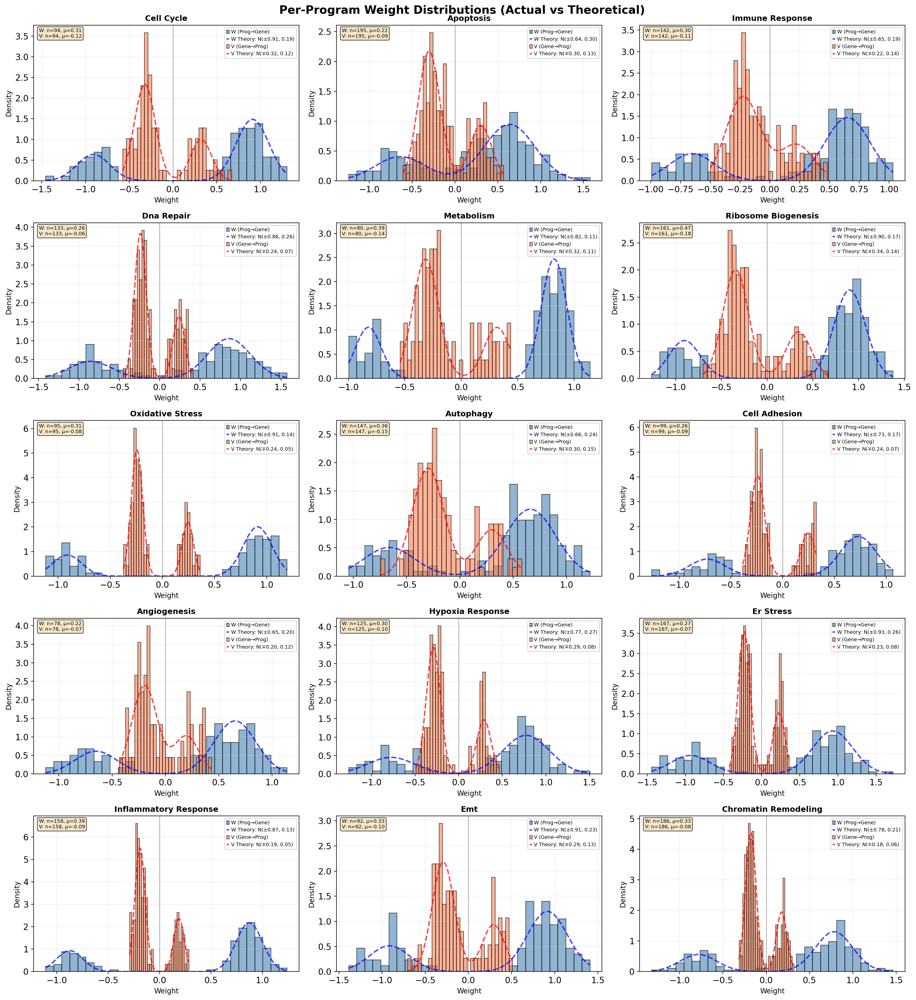

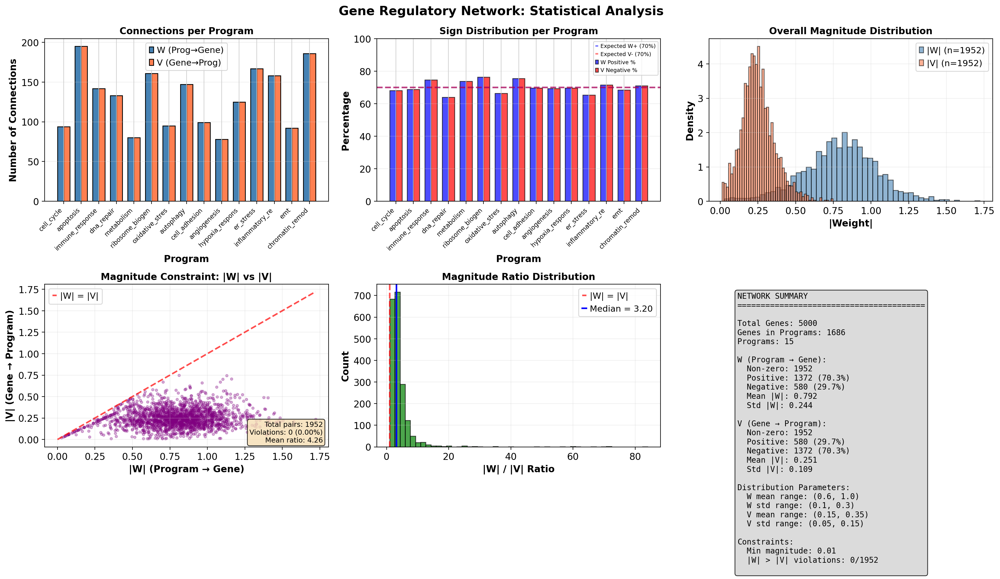


✓ Visualizations saved:
  - my_grn_matrices.png
  - my_grn_distributions.png
  - my_grn_statistics.png


In [6]:
def visualize_grn_comprehensive(grn, save_prefix='grn_visualization', dpi=300):
    """
    Comprehensive visualization of the Gene Regulatory Network.
    
    Creates multiple figures showing:
    1. Matrix heatmaps (W and V)
    2. Per-program distributions
    3. Network statistics
    4. Sign patterns
    5. Magnitude relationships
    """
    
    # ================================================================
    # FIGURE 1: MATRIX HEATMAPS
    # ================================================================
    
    fig1 = plt.figure(figsize=(20, 10))
    gs1 = fig1.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # --- W Matrix Heatmap (Full) ---
    ax1 = fig1.add_subplot(gs1[0, 0])
    
    # Only show genes with at least one non-zero connection
    w_gene_mask = np.any(grn.W != 0, axis=1)
    w_genes_to_show = np.where(w_gene_mask)[0]
    
    w_subset = grn.W[w_genes_to_show, :]
    
    im1 = ax1.imshow(w_subset, aspect='auto', cmap='RdBu_r', 
                     vmin=-np.abs(w_subset).max(), vmax=np.abs(w_subset).max())
    ax1.set_title('W Matrix: Program → Gene\n(Only genes in programs shown)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Programs', fontsize=12, fontweight='bold')
    ax1.set_ylabel(f'Genes ({len(w_genes_to_show)} with connections)', 
                   fontsize=12, fontweight='bold')
    
    # Set program names on x-axis
    ax1.set_xticks(range(grn.n_programs))
    ax1.set_xticklabels([name[:15] for name in grn.program_names], 
                        rotation=45, ha='right', fontsize=8)
    
    # Colorbar
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('Weight', fontsize=10, fontweight='bold')
    
    # --- V Matrix Heatmap (Full) ---
    ax2 = fig1.add_subplot(gs1[0, 1])
    
    # Only show genes with at least one non-zero connection
    v_gene_mask = np.any(grn.V != 0, axis=0)
    v_genes_to_show = np.where(v_gene_mask)[0]
    
    v_subset = grn.V[:, v_genes_to_show]
    
    im2 = ax2.imshow(v_subset, aspect='auto', cmap='RdBu_r',
                     vmin=-np.abs(v_subset).max(), vmax=np.abs(v_subset).max())
    ax2.set_title('V Matrix: Gene → Program\n(Only genes in programs shown)',
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel(f'Genes ({len(v_genes_to_show)} with connections)', 
                   fontsize=12, fontweight='bold')
    ax2.set_ylabel('Programs', fontsize=12, fontweight='bold')
    
    # Set program names on y-axis
    ax2.set_yticks(range(grn.n_programs))
    ax2.set_yticklabels([name[:15] for name in grn.program_names], fontsize=8)
    
    # Colorbar
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('Weight', fontsize=10, fontweight='bold')
    
    # --- W Matrix Zoomed (per-program structure) ---
    ax3 = fig1.add_subplot(gs1[1, 0])
    
    # Sort genes by their primary program
    gene_to_primary_program = {}
    for prog_idx, (prog_name, prog_info) in enumerate(grn.programs.items()):
        for gene in prog_info['genes']:
            if gene in grn.gene_to_idx and gene not in gene_to_primary_program:
                gene_to_primary_program[gene] = prog_idx
    
    sorted_gene_indices = sorted(
        w_genes_to_show,
        key=lambda g: gene_to_primary_program.get(grn.all_genes[g], -1)
    )
    
    w_sorted = grn.W[sorted_gene_indices, :]
    
    im3 = ax3.imshow(w_sorted, aspect='auto', cmap='RdBu_r',
                     vmin=-np.abs(w_sorted).max(), vmax=np.abs(w_sorted).max())
    ax3.set_title('W Matrix: Genes Sorted by Primary Program',
                  fontsize=14, fontweight='bold')
    ax3.set_xlabel('Programs', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Genes (sorted)', fontsize=12, fontweight='bold')
    
    ax3.set_xticks(range(grn.n_programs))
    ax3.set_xticklabels([name[:15] for name in grn.program_names],
                        rotation=45, ha='right', fontsize=8)
    
    # Draw boxes around program blocks
    cumsum = 0
    for prog_idx in range(grn.n_programs):
        prog_genes = [g for g in sorted_gene_indices 
                     if gene_to_primary_program.get(grn.all_genes[g], -1) == prog_idx]
        if len(prog_genes) > 0:
            rect = Rectangle((prog_idx - 0.5, cumsum - 0.5), 1, len(prog_genes),
                           linewidth=2, edgecolor='black', facecolor='none')
            ax3.add_patch(rect)
            cumsum += len(prog_genes)
    
    cbar3 = plt.colorbar(im3, ax=ax3)
    cbar3.set_label('Weight', fontsize=10, fontweight='bold')
    
    # --- Distribution Parameters Table ---
    ax4 = fig1.add_subplot(gs1[1, 1])
    ax4.axis('off')
    
    # Create table data
    table_data = []
    dist_params = grn.get_program_distributions()
    
    for prog_name in grn.program_names:
        w_params = dist_params['W'][prog_name]
        v_params = dist_params['V'][prog_name]
        
        # Get actual stats
        prog_idx = grn.program_to_idx[prog_name]
        w_col = grn.W[:, prog_idx]
        w_nonzero = w_col[w_col != 0]
        v_row = grn.V[prog_idx, :]
        v_nonzero = v_row[v_row != 0]
        
        table_data.append([
            prog_name[:20],
            f"{w_params['mean']:.2f}",
            f"{w_params['std']:.2f}",
            f"{np.abs(w_nonzero).mean():.2f}" if len(w_nonzero) > 0 else "0.00",
            f"{v_params['mean']:.2f}",
            f"{v_params['std']:.2f}",
            f"{np.abs(v_nonzero).mean():.2f}" if len(v_nonzero) > 0 else "0.00",
        ])
    
    table = ax4.table(cellText=table_data,
                     colLabels=['Program', 'W μ', 'W σ', 'W |mean|', 
                               'V μ', 'V σ', 'V |mean|'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1, 1.5)
    
    # Color header
    for i in range(7):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax4.set_title('Distribution Parameters vs Actual', 
                 fontsize=14, fontweight='bold', pad=20)
    
    plt.suptitle('Gene Regulatory Network: Matrix Visualization',
                fontsize=16, fontweight='bold', y=0.98)
    
    plt.savefig(f'{save_prefix}_matrices.png', dpi=dpi, bbox_inches='tight')
    plt.show()
    
    # ================================================================
    # FIGURE 2: PER-PROGRAM DISTRIBUTIONS
    # ================================================================
    
    n_programs = grn.n_programs
    n_rows = (n_programs + 2) // 3
    
    fig2, axes2 = plt.subplots(n_rows, 3, figsize=(18, 4*n_rows))
    axes2 = axes2.flatten() if n_programs > 3 else [axes2] if n_programs == 1 else axes2
    
    dist_params = grn.get_program_distributions()
    
    for prog_idx, prog_name in enumerate(grn.program_names):
        ax = axes2[prog_idx]
        
        # Get weights for this program
        w_col = grn.W[:, prog_idx]
        w_nonzero = w_col[w_col != 0]
        
        v_row = grn.V[prog_idx, :]
        v_nonzero = v_row[v_row != 0]
        
        # Plot W distribution
        if len(w_nonzero) > 0:
            ax.hist(w_nonzero, bins=30, alpha=0.6, label='W (Prog→Gene)',
                   color='steelblue', edgecolor='black', density=True)
            
            # Overlay theoretical Gaussian
            w_params = dist_params['W'][prog_name]
            x_w = np.linspace(w_nonzero.min(), w_nonzero.max(), 100)
            
            # Positive component
            y_w_pos = grn.w_activation_prob * (1/(w_params['std']*np.sqrt(2*np.pi))) * \
                     np.exp(-0.5*((x_w - w_params['mean'])/w_params['std'])**2)
            # Negative component
            y_w_neg = (1-grn.w_activation_prob) * (1/(w_params['std']*np.sqrt(2*np.pi))) * \
                     np.exp(-0.5*((x_w + w_params['mean'])/w_params['std'])**2)
            
            ax.plot(x_w, y_w_pos + y_w_neg, 'b--', linewidth=2, alpha=0.7,
                   label=f'W Theory: N(±{w_params["mean"]:.2f}, {w_params["std"]:.2f})')
        
        # Plot V distribution
        if len(v_nonzero) > 0:
            ax.hist(v_nonzero, bins=30, alpha=0.6, label='V (Gene→Prog)',
                   color='coral', edgecolor='black', density=True)
            
            # Overlay theoretical Gaussian
            v_params = dist_params['V'][prog_name]
            x_v = np.linspace(v_nonzero.min(), v_nonzero.max(), 100)
            
            # Negative component (majority)
            y_v_neg = grn.v_negative_prob * (1/(v_params['std']*np.sqrt(2*np.pi))) * \
                     np.exp(-0.5*((x_v + v_params['mean'])/v_params['std'])**2)
            # Positive component
            y_v_pos = (1-grn.v_negative_prob) * (1/(v_params['std']*np.sqrt(2*np.pi))) * \
                     np.exp(-0.5*((x_v - v_params['mean'])/v_params['std'])**2)
            
            ax.plot(x_v, y_v_neg + y_v_pos, 'r--', linewidth=2, alpha=0.7,
                   label=f'V Theory: N(∓{v_params["mean"]:.2f}, {v_params["std"]:.2f})')
        
        ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
        ax.set_title(f'{prog_name.replace("_", " ").title()}',
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('Weight', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.legend(fontsize=7, loc='best')
        ax.grid(alpha=0.3)
        
        # Add statistics
        if len(w_nonzero) > 0 and len(v_nonzero) > 0:
            stats_text = f'W: n={len(w_nonzero)}, μ={w_nonzero.mean():.2f}\n'
            stats_text += f'V: n={len(v_nonzero)}, μ={v_nonzero.mean():.2f}'
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                   verticalalignment='top', fontsize=7,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # Hide unused subplots
    for idx in range(n_programs, len(axes2)):
        axes2[idx].axis('off')
    
    plt.suptitle('Per-Program Weight Distributions (Actual vs Theoretical)',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_distributions.png', dpi=dpi, bbox_inches='tight')
    plt.show()
    
    # ================================================================
    # FIGURE 3: NETWORK STATISTICS
    # ================================================================
    
    fig3, axes3 = plt.subplots(2, 3, figsize=(18, 10))
    
    # --- Sparsity per program ---
    ax1 = axes3[0, 0]
    
    sparsity_data = []
    for prog_idx, prog_name in enumerate(grn.program_names):
        w_col = grn.W[:, prog_idx]
        v_row = grn.V[prog_idx, :]
        
        w_nonzero = (w_col != 0).sum()
        v_nonzero = (v_row != 0).sum()
        
        sparsity_data.append({
            'Program': prog_name[:15],
            'W_Connections': w_nonzero,
            'V_Connections': v_nonzero
        })
    
    sp_df = pd.DataFrame(sparsity_data)
    
    x = np.arange(len(sp_df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, sp_df['W_Connections'], width,
                   label='W (Prog→Gene)', color='steelblue', edgecolor='black')
    bars2 = ax1.bar(x + width/2, sp_df['V_Connections'], width,
                   label='V (Gene→Prog)', color='coral', edgecolor='black')
    
    ax1.set_xlabel('Program', fontweight='bold')
    ax1.set_ylabel('Number of Connections', fontweight='bold')
    ax1.set_title('Connections per Program', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(sp_df['Program'], rotation=45, ha='right', fontsize=8)
    ax1.legend()
    ax1.grid(alpha=0.3, axis='y')
    
    # --- Sign distribution per program ---
    ax2 = axes3[0, 1]
    
    sign_data = []
    for prog_idx, prog_name in enumerate(grn.program_names):
        w_col = grn.W[:, prog_idx]
        w_pos = (w_col > 0).sum()
        w_neg = (w_col < 0).sum()
        
        v_row = grn.V[prog_idx, :]
        v_pos = (v_row > 0).sum()
        v_neg = (v_row < 0).sum()
        
        sign_data.append({
            'Program': prog_name[:15],
            'W_Pos': w_pos,
            'W_Neg': w_neg,
            'V_Pos': v_pos,
            'V_Neg': v_neg,
            'W_Pos_Pct': w_pos / (w_pos + w_neg) * 100 if (w_pos + w_neg) > 0 else 0,
            'V_Neg_Pct': v_neg / (v_pos + v_neg) * 100 if (v_pos + v_neg) > 0 else 0
        })
    
    sign_df = pd.DataFrame(sign_data)
    
    bars1 = ax2.bar(x - width/2, sign_df['W_Pos_Pct'], width,
                   label='W Positive %', color='blue', alpha=0.7, edgecolor='black')
    bars2 = ax2.bar(x + width/2, sign_df['V_Neg_Pct'], width,
                   label='V Negative %', color='red', alpha=0.7, edgecolor='black')
    
    ax2.axhline(grn.w_activation_prob * 100, color='blue', linestyle='--',
               linewidth=2, alpha=0.5, label=f'Expected W+ ({grn.w_activation_prob*100:.0f}%)')
    ax2.axhline(grn.v_negative_prob * 100, color='red', linestyle='--',
               linewidth=2, alpha=0.5, label=f'Expected V- ({grn.v_negative_prob*100:.0f}%)')
    
    ax2.set_xlabel('Program', fontweight='bold')
    ax2.set_ylabel('Percentage', fontweight='bold')
    ax2.set_title('Sign Distribution per Program', fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(sign_df['Program'], rotation=45, ha='right', fontsize=8)
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.3, axis='y')
    ax2.set_ylim([0, 100])
    
    # --- Magnitude distribution overall ---
    ax3 = axes3[0, 2]
    
    w_all_nonzero = grn.W[grn.W != 0]
    v_all_nonzero = grn.V[grn.V != 0]
    
    ax3.hist(np.abs(w_all_nonzero), bins=50, alpha=0.6, 
            label=f'|W| (n={len(w_all_nonzero)})',
            color='steelblue', edgecolor='black', density=True)
    ax3.hist(np.abs(v_all_nonzero), bins=50, alpha=0.6,
            label=f'|V| (n={len(v_all_nonzero)})',
            color='coral', edgecolor='black', density=True)
    
    ax3.set_xlabel('|Weight|', fontweight='bold')
    ax3.set_ylabel('Density', fontweight='bold')
    ax3.set_title('Overall Magnitude Distribution', fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # --- |W| vs |V| scatter ---
    ax4 = axes3[1, 0]
    
    comparison_data = []
    for gene_idx in range(grn.n_genes):
        for prog_idx in range(grn.n_programs):
            w_val = grn.W[gene_idx, prog_idx]
            v_val = grn.V[prog_idx, gene_idx]
            
            if w_val != 0 and v_val != 0:
                comparison_data.append({
                    '|W|': abs(w_val),
                    '|V|': abs(v_val),
                    'Ratio': abs(w_val) / abs(v_val)
                })
    
    comp_df = pd.DataFrame(comparison_data)
    
    if len(comp_df) > 0:
        ax4.scatter(comp_df['|W|'], comp_df['|V|'], alpha=0.3, s=10, color='purple')
        
        max_val = max(comp_df['|W|'].max(), comp_df['|V|'].max())
        ax4.plot([0, max_val], [0, max_val], 'r--', linewidth=2, 
                label='|W| = |V|', alpha=0.7)
        
        ax4.set_xlabel('|W| (Program → Gene)', fontweight='bold')
        ax4.set_ylabel('|V| (Gene → Program)', fontweight='bold')
        ax4.set_title('Magnitude Constraint: |W| vs |V|', fontweight='bold')
        ax4.legend()
        ax4.grid(alpha=0.3)
        
        # Count violations
        violations = (comp_df['Ratio'] < 1).sum()
        total = len(comp_df)
        
        text = f'Total pairs: {total}\n'
        text += f'Violations: {violations} ({violations/total*100:.2f}%)\n'
        text += f'Mean ratio: {comp_df["Ratio"].mean():.2f}'
        
        ax4.text(0.98, 0.02, text, transform=ax4.transAxes,
                verticalalignment='bottom', horizontalalignment='right',
                fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # --- Ratio histogram ---
    ax5 = axes3[1, 1]
    
    if len(comp_df) > 0:
        ax5.hist(comp_df['Ratio'], bins=50, alpha=0.7, color='green',
                edgecolor='black')
        ax5.axvline(1, color='red', linestyle='--', linewidth=2,
                   label='|W| = |V|', alpha=0.7)
        ax5.axvline(comp_df['Ratio'].median(), color='blue', linestyle='-',
                   linewidth=2, label=f'Median = {comp_df["Ratio"].median():.2f}')
        
        ax5.set_xlabel('|W| / |V| Ratio', fontweight='bold')
        ax5.set_ylabel('Count', fontweight='bold')
        ax5.set_title('Magnitude Ratio Distribution', fontweight='bold')
        ax5.legend()
        ax5.grid(alpha=0.3)
    
    # --- Parameter ranges ---
    ax6 = axes3[1, 2]
    ax6.axis('off')
    
    summary_text = "NETWORK SUMMARY\n"
    summary_text += "="*40 + "\n\n"
    summary_text += f"Total Genes: {grn.n_genes}\n"
    summary_text += f"Genes in Programs: {len(grn.get_genes_in_programs())}\n"
    summary_text += f"Programs: {grn.n_programs}\n\n"
    
    summary_text += f"W (Program → Gene):\n"
    summary_text += f"  Non-zero: {(grn.W != 0).sum()}\n"
    summary_text += f"  Positive: {(grn.W > 0).sum()} ({(grn.W > 0).sum()/(grn.W != 0).sum()*100:.1f}%)\n"
    summary_text += f"  Negative: {(grn.W < 0).sum()} ({(grn.W < 0).sum()/(grn.W != 0).sum()*100:.1f}%)\n"
    summary_text += f"  Mean |W|: {np.abs(grn.W[grn.W != 0]).mean():.3f}\n"
    summary_text += f"  Std |W|: {np.abs(grn.W[grn.W != 0]).std():.3f}\n\n"
    
    summary_text += f"V (Gene → Program):\n"
    summary_text += f"  Non-zero: {(grn.V != 0).sum()}\n"
    summary_text += f"  Positive: {(grn.V > 0).sum()} ({(grn.V > 0).sum()/(grn.V != 0).sum()*100:.1f}%)\n"
    summary_text += f"  Negative: {(grn.V < 0).sum()} ({(grn.V < 0).sum()/(grn.V != 0).sum()*100:.1f}%)\n"
    summary_text += f"  Mean |V|: {np.abs(grn.V[grn.V != 0]).mean():.3f}\n"
    summary_text += f"  Std |V|: {np.abs(grn.V[grn.V != 0]).std():.3f}\n\n"
    
    summary_text += f"Distribution Parameters:\n"
    summary_text += f"  W mean range: {grn.w_mean_range}\n"
    summary_text += f"  W std range: {grn.w_std_range}\n"
    summary_text += f"  V mean range: {grn.v_mean_range}\n"
    summary_text += f"  V std range: {grn.v_std_range}\n\n"
    
    summary_text += f"Constraints:\n"
    summary_text += f"  Min magnitude: {grn.min_magnitude}\n"
    if len(comp_df) > 0:
        summary_text += f"  |W| > |V| violations: {violations}/{total}\n"
    
    ax6.text(0.1, 0.95, summary_text, transform=ax6.transAxes,
            verticalalignment='top', fontsize=10, family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.suptitle('Gene Regulatory Network: Statistical Analysis',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_statistics.png', dpi=dpi, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Visualizations saved:")
    print(f"  - {save_prefix}_matrices.png")
    print(f"  - {save_prefix}_distributions.png")
    print(f"  - {save_prefix}_statistics.png")


# ============================================================
# USAGE
# ============================================================

visualize_grn_comprehensive(
    grn,
    save_prefix='my_grn',
    dpi=300
)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
import matplotlib.patches as mpatches
from typing import Dict, List, Set
import warnings
warnings.filterwarnings('ignore')


def visualize_grn_complete(grn, go_gen):
    """
    Complete visualization of GRN showing real vs synthetic genes.
    
    Parameters:
    -----------
    grn : GeneRegulatoryNetwork
        The gene regulatory network
    go_gen : GOProgramGenerator
        The gene program generator (to identify real vs synthetic genes)
    """
    
    # Get gene classifications
    real_genes = go_gen.get_real_genes()
    synthetic_genes = go_gen.get_synthetic_genes()
    shared_synthetic = go_gen.get_shared_synthetic_genes()
    
    # Classify all genes
    gene_types = {}
    for gene in grn.all_genes:
        if gene in real_genes:
            gene_types[gene] = 'real'
        elif gene in shared_synthetic:
            gene_types[gene] = 'shared_synthetic'
        elif gene in synthetic_genes:
            gene_types[gene] = 'unique_synthetic'
        else:
            gene_types[gene] = 'filler'
    
    # Plot all figures
    plot_matrix_heatmaps(grn, gene_types)
    plot_distributions_by_gene_type(grn, gene_types)
    plot_per_program_analysis(grn, go_gen, gene_types)
    plot_network_schematic(grn, go_gen, gene_types)
    plot_gene_type_statistics(grn, go_gen, gene_types)


def plot_matrix_heatmaps(grn, gene_types):
    """Plot W and V matrices with gene type color coding."""
    
    fig = plt.figure(figsize=(24, 12))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3, width_ratios=[1, 1, 0.05])
    
    # Get genes in programs only
    genes_in_programs = [g for g in grn.all_genes 
                        if gene_types[g] in ['real', 'shared_synthetic', 'unique_synthetic']]
    gene_indices = [grn.gene_to_idx[g] for g in genes_in_programs]
    
    # Create color map for gene types
    gene_type_colors = {
        'real': '#2E86AB',  # Blue
        'shared_synthetic': '#A23B72',  # Purple
        'unique_synthetic': '#F18F01',  # Orange
        'filler': '#CCCCCC'  # Gray
    }
    
    # --- W Matrix ---
    ax1 = fig.add_subplot(gs[0, 0])
    
    W_subset = grn.W[gene_indices, :]
    
    im1 = ax1.imshow(W_subset, aspect='auto', cmap='RdBu_r',
                     vmin=-np.abs(W_subset).max(), vmax=np.abs(W_subset).max())
    
    ax1.set_title('W Matrix: Program → Gene\n(Rows colored by gene type)',
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Programs', fontsize=12, fontweight='bold')
    ax1.set_ylabel(f'Genes ({len(gene_indices)} in programs)', fontsize=12, fontweight='bold')
    
    ax1.set_xticks(range(grn.n_programs))
    ax1.set_xticklabels([name[:15] for name in grn.program_names],
                        rotation=45, ha='right', fontsize=9)
    
    # Add gene type color bars on the left
    for i, gene in enumerate(genes_in_programs):
        color = gene_type_colors[gene_types[gene]]
        ax1.add_patch(Rectangle((-0.5, i-0.5), 0.5, 1, 
                                facecolor=color, edgecolor='none',
                                transform=ax1.transData, clip_on=False))
    
    # Colorbar for W
    cbar_ax1 = fig.add_subplot(gs[0, 2])
    cbar1 = plt.colorbar(im1, cax=cbar_ax1)
    cbar1.set_label('Weight', fontsize=11, fontweight='bold')
    
    # --- V Matrix ---
    ax2 = fig.add_subplot(gs[1, 0])
    
    V_subset = grn.V[:, gene_indices]
    
    im2 = ax2.imshow(V_subset, aspect='auto', cmap='RdBu_r',
                     vmin=-np.abs(V_subset).max(), vmax=np.abs(V_subset).max())
    
    ax2.set_title('V Matrix: Gene → Program\n(Columns colored by gene type)',
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel(f'Genes ({len(gene_indices)} in programs)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Programs', fontsize=12, fontweight='bold')
    
    ax2.set_yticks(range(grn.n_programs))
    ax2.set_yticklabels([name[:15] for name in grn.program_names], fontsize=9)
    
    # Add gene type color bars on the bottom
    for i, gene in enumerate(genes_in_programs):
        color = gene_type_colors[gene_types[gene]]
        ax2.add_patch(Rectangle((i-0.5, grn.n_programs-0.5), 1, 0.5,
                                facecolor=color, edgecolor='none',
                                transform=ax2.transData, clip_on=False))
    
    # Colorbar for V
    cbar_ax2 = fig.add_subplot(gs[1, 2])
    cbar2 = plt.colorbar(im2, cax=cbar_ax2)
    cbar2.set_label('Weight', fontsize=11, fontweight='bold')
    
    # --- W Matrix sorted by gene type ---
    ax3 = fig.add_subplot(gs[0, 1])
    
    # Sort genes by type
    sorted_genes = sorted(genes_in_programs, 
                         key=lambda g: (gene_types[g], g))
    sorted_indices = [grn.gene_to_idx[g] for g in sorted_genes]
    
    W_sorted = grn.W[sorted_indices, :]
    
    im3 = ax3.imshow(W_sorted, aspect='auto', cmap='RdBu_r',
                     vmin=-np.abs(W_sorted).max(), vmax=np.abs(W_sorted).max())
    
    ax3.set_title('W Matrix: Sorted by Gene Type',
                  fontsize=14, fontweight='bold')
    ax3.set_xlabel('Programs', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Genes (sorted by type)', fontsize=12, fontweight='bold')
    
    ax3.set_xticks(range(grn.n_programs))
    ax3.set_xticklabels([name[:15] for name in grn.program_names],
                        rotation=45, ha='right', fontsize=9)
    
    # Add gene type blocks
    current_type = None
    start_idx = 0
    for i, gene in enumerate(sorted_genes):
        if gene_types[gene] != current_type:
            if current_type is not None:
                # Draw rectangle for previous block
                color = gene_type_colors[current_type]
                height = i - start_idx
                ax3.add_patch(Rectangle((-0.5, start_idx-0.5), 0.5, height,
                                       facecolor=color, edgecolor='black',
                                       linewidth=1.5,
                                       transform=ax3.transData, clip_on=False))
            current_type = gene_types[gene]
            start_idx = i
    
    # Draw last block
    if current_type is not None:
        color = gene_type_colors[current_type]
        height = len(sorted_genes) - start_idx
        ax3.add_patch(Rectangle((-0.5, start_idx-0.5), 0.5, height,
                               facecolor=color, edgecolor='black',
                               linewidth=1.5,
                               transform=ax3.transData, clip_on=False))
    
    # --- V Matrix sorted by gene type ---
    ax4 = fig.add_subplot(gs[1, 1])
    
    V_sorted = grn.V[:, sorted_indices]
    
    im4 = ax4.imshow(V_sorted, aspect='auto', cmap='RdBu_r',
                     vmin=-np.abs(V_sorted).max(), vmax=np.abs(V_sorted).max())
    
    ax4.set_title('V Matrix: Sorted by Gene Type',
                  fontsize=14, fontweight='bold')
    ax4.set_xlabel('Genes (sorted by type)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Programs', fontsize=12, fontweight='bold')
    
    ax4.set_yticks(range(grn.n_programs))
    ax4.set_yticklabels([name[:15] for name in grn.program_names], fontsize=9)
    
    # Add gene type blocks on bottom
    current_type = None
    start_idx = 0
    for i, gene in enumerate(sorted_genes):
        if gene_types[gene] != current_type:
            if current_type is not None:
                color = gene_type_colors[current_type]
                width = i - start_idx
                ax4.add_patch(Rectangle((start_idx-0.5, grn.n_programs-0.5), width, 0.5,
                                       facecolor=color, edgecolor='black',
                                       linewidth=1.5,
                                       transform=ax4.transData, clip_on=False))
            current_type = gene_types[gene]
            start_idx = i
    
    if current_type is not None:
        color = gene_type_colors[current_type]
        width = len(sorted_genes) - start_idx
        ax4.add_patch(Rectangle((start_idx-0.5, grn.n_programs-0.5), width, 0.5,
                               facecolor=color, edgecolor='black',
                               linewidth=1.5,
                               transform=ax4.transData, clip_on=False))
    
    # Legend
    legend_elements = [
        mpatches.Patch(facecolor=gene_type_colors['real'], 
                      edgecolor='black', label='Real GO Genes'),
        mpatches.Patch(facecolor=gene_type_colors['shared_synthetic'],
                      edgecolor='black', label='Shared Synthetic'),
        mpatches.Patch(facecolor=gene_type_colors['unique_synthetic'],
                      edgecolor='black', label='Unique Synthetic'),
    ]
    
    fig.legend(handles=legend_elements, loc='upper center',
              bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=11,
              framealpha=0.9)
    
    plt.suptitle('Gene Regulatory Network Matrices: Real vs Synthetic Genes',
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.show()


def plot_distributions_by_gene_type(grn, gene_types):
    """Plot W and V distributions separated by gene type."""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    gene_type_colors = {
        'real': '#2E86AB',
        'shared_synthetic': '#A23B72',
        'unique_synthetic': '#F18F01',
        'filler': '#CCCCCC'
    }
    
    # Collect W and V values by gene type
    w_by_type = {gt: [] for gt in gene_type_colors.keys()}
    v_by_type = {gt: [] for gt in gene_type_colors.keys()}
    
    for gene in grn.all_genes:
        gene_idx = grn.gene_to_idx[gene]
        gtype = gene_types[gene]
        
        # W values for this gene
        w_vals = grn.W[gene_idx, :]
        w_nonzero = w_vals[w_vals != 0]
        w_by_type[gtype].extend(w_nonzero)
        
        # V values for this gene
        v_vals = grn.V[:, gene_idx]
        v_nonzero = v_vals[v_vals != 0]
        v_by_type[gtype].extend(v_nonzero)
    
    # --- W distributions ---
    ax1 = axes[0, 0]
    for gtype in ['real', 'shared_synthetic', 'unique_synthetic']:
        if len(w_by_type[gtype]) > 0:
            ax1.hist(w_by_type[gtype], bins=50, alpha=0.6,
                    label=gtype.replace('_', ' ').title(),
                    color=gene_type_colors[gtype], edgecolor='black')
    
    ax1.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax1.set_xlabel('Weight', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax1.set_title('W Distribution by Gene Type', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)
    
    # --- V distributions ---
    ax2 = axes[0, 1]
    for gtype in ['real', 'shared_synthetic', 'unique_synthetic']:
        if len(v_by_type[gtype]) > 0:
            ax2.hist(v_by_type[gtype], bins=50, alpha=0.6,
                    label=gtype.replace('_', ' ').title(),
                    color=gene_type_colors[gtype], edgecolor='black')
    
    ax2.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Weight', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax2.set_title('V Distribution by Gene Type', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)
    
    # --- Magnitude comparison ---
    ax3 = axes[0, 2]
    data_for_box = []
    labels_for_box = []
    
    for gtype in ['real', 'shared_synthetic', 'unique_synthetic']:
        if len(w_by_type[gtype]) > 0:
            data_for_box.append(np.abs(w_by_type[gtype]))
            labels_for_box.append(f'W\n{gtype[:6]}')
        if len(v_by_type[gtype]) > 0:
            data_for_box.append(np.abs(v_by_type[gtype]))
            labels_for_box.append(f'V\n{gtype[:6]}')
    
    bp = ax3.boxplot(data_for_box, labels=labels_for_box, patch_artist=True)
    
    # Color boxes
    colors = []
    for label in labels_for_box:
        if 'real' in label.lower():
            colors.append(gene_type_colors['real'])
        elif 'shared' in label.lower():
            colors.append(gene_type_colors['shared_synthetic'])
        else:
            colors.append(gene_type_colors['unique_synthetic'])
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax3.set_ylabel('|Weight|', fontsize=11, fontweight='bold')
    ax3.set_title('Magnitude Comparison', fontsize=12, fontweight='bold')
    ax3.tick_params(axis='x', labelsize=8)
    ax3.grid(alpha=0.3, axis='y')
    
    # --- Sign distribution ---
    ax4 = axes[1, 0]
    
    sign_data = []
    for gtype in ['real', 'shared_synthetic', 'unique_synthetic']:
        if len(w_by_type[gtype]) > 0:
            n_pos = sum(1 for x in w_by_type[gtype] if x > 0)
            n_neg = sum(1 for x in w_by_type[gtype] if x < 0)
            sign_data.append({
                'Type': f"{gtype.replace('_', ' ').title()}\n(W)",
                'Positive': n_pos,
                'Negative': n_neg,
                'Color': gene_type_colors[gtype]
            })
        if len(v_by_type[gtype]) > 0:
            n_pos = sum(1 for x in v_by_type[gtype] if x > 0)
            n_neg = sum(1 for x in v_by_type[gtype] if x < 0)
            sign_data.append({
                'Type': f"{gtype.replace('_', ' ').title()}\n(V)",
                'Positive': n_pos,
                'Negative': n_neg,
                'Color': gene_type_colors[gtype]
            })
    
    x = np.arange(len(sign_data))
    width = 0.35
    
    bars1 = ax4.bar(x - width/2, [d['Positive'] for d in sign_data], width,
                   label='Positive', color='blue', alpha=0.6, edgecolor='black')
    bars2 = ax4.bar(x + width/2, [d['Negative'] for d in sign_data], width,
                   label='Negative', color='red', alpha=0.6, edgecolor='black')
    
    ax4.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax4.set_title('Sign Distribution by Gene Type', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels([d['Type'] for d in sign_data], fontsize=8)
    ax4.legend(fontsize=9)
    ax4.grid(alpha=0.3, axis='y')
    
    # --- Connection counts ---
    ax5 = axes[1, 1]
    
    conn_data = []
    for gtype in ['real', 'shared_synthetic', 'unique_synthetic']:
        n_genes = sum(1 for g in grn.all_genes if gene_types[g] == gtype)
        n_w_conn = len(w_by_type[gtype])
        n_v_conn = len(v_by_type[gtype])
        
        if n_genes > 0:
            conn_data.append({
                'Type': gtype.replace('_', ' ').title(),
                'W_connections': n_w_conn,
                'V_connections': n_v_conn,
                'Genes': n_genes,
                'Color': gene_type_colors[gtype]
            })
    
    x = np.arange(len(conn_data))
    width = 0.35
    
    bars1 = ax5.bar(x - width/2, [d['W_connections'] for d in conn_data], width,
                   label='W connections', color='steelblue', edgecolor='black')
    bars2 = ax5.bar(x + width/2, [d['V_connections'] for d in conn_data], width,
                   label='V connections', color='coral', edgecolor='black')
    
    ax5.set_ylabel('Number of Connections', fontsize=11, fontweight='bold')
    ax5.set_title('Total Connections by Gene Type', fontsize=12, fontweight='bold')
    ax5.set_xticks(x)
    ax5.set_xticklabels([d['Type'] for d in conn_data], fontsize=9)
    ax5.legend(fontsize=9)
    ax5.grid(alpha=0.3, axis='y')
    
    # Add gene counts on top
    for i, d in enumerate(conn_data):
        ax5.text(i, max(d['W_connections'], d['V_connections']) * 1.05,
                f"n={d['Genes']}", ha='center', fontsize=8)
    
    # --- Statistics table ---
    ax6 = axes[1, 2]
    ax6.axis('off')
    
    stats_text = "STATISTICS BY GENE TYPE\n" + "="*40 + "\n\n"
    
    for gtype in ['real', 'shared_synthetic', 'unique_synthetic']:
        n_genes = sum(1 for g in grn.all_genes if gene_types[g] == gtype)
        
        if n_genes > 0:
            stats_text += f"{gtype.replace('_', ' ').upper()}:\n"
            stats_text += f"  Genes: {n_genes}\n"
            
            if len(w_by_type[gtype]) > 0:
                w_vals = np.array(w_by_type[gtype])
                stats_text += f"  W connections: {len(w_vals)}\n"
                stats_text += f"    Mean: {w_vals.mean():.3f}\n"
                stats_text += f"    Std: {w_vals.std():.3f}\n"
                stats_text += f"    |Mean|: {np.abs(w_vals).mean():.3f}\n"
            
            if len(v_by_type[gtype]) > 0:
                v_vals = np.array(v_by_type[gtype])
                stats_text += f"  V connections: {len(v_vals)}\n"
                stats_text += f"    Mean: {v_vals.mean():.3f}\n"
                stats_text += f"    Std: {v_vals.std():.3f}\n"
                stats_text += f"    |Mean|: {np.abs(v_vals).mean():.3f}\n"
            
            stats_text += "\n"
    
    ax6.text(0.05, 0.95, stats_text, transform=ax6.transAxes,
            verticalalignment='top', fontsize=9, family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Weight Distributions by Gene Type (Real vs Synthetic)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_per_program_analysis(grn, go_gen, gene_types):
    """Analyze W and V per program, separated by gene type."""
    
    n_programs = grn.n_programs
    n_cols = 3
    n_rows = (n_programs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    axes = axes.flatten() if n_programs > 1 else [axes]
    
    gene_type_colors = {
        'real': '#2E86AB',
        'shared_synthetic': '#A23B72',
        'unique_synthetic': '#F18F01',
    }
    
    for prog_idx, prog_name in enumerate(grn.program_names):
        ax = axes[prog_idx]
        
        # Get W and V for this program
        w_col = grn.W[:, prog_idx]
        v_row = grn.V[prog_idx, :]
        
        # Separate by gene type
        w_by_type = {'real': [], 'shared_synthetic': [], 'unique_synthetic': []}
        v_by_type = {'real': [], 'shared_synthetic': [], 'unique_synthetic': []}
        
        for gene_idx, gene in enumerate(grn.all_genes):
            gtype = gene_types[gene]
            if gtype in w_by_type:
                if w_col[gene_idx] != 0:
                    w_by_type[gtype].append(w_col[gene_idx])
                if v_row[gene_idx] != 0:
                    v_by_type[gtype].append(v_row[gene_idx])
        
        # Plot histograms
        all_w = []
        all_v = []
        
        for gtype in ['real', 'shared_synthetic', 'unique_synthetic']:
            if len(w_by_type[gtype]) > 0:
                ax.hist(w_by_type[gtype], bins=20, alpha=0.5,
                       label=f'W {gtype[:6]}',
                       color=gene_type_colors[gtype], edgecolor='black',
                       histtype='stepfilled')
                all_w.extend(w_by_type[gtype])
            
            if len(v_by_type[gtype]) > 0:
                ax.hist(v_by_type[gtype], bins=20, alpha=0.3,
                       label=f'V {gtype[:6]}',
                       color=gene_type_colors[gtype], edgecolor='black',
                       histtype='step', linewidth=2, linestyle='--')
                all_v.extend(v_by_type[gtype])
        
        ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        ax.set_title(prog_name.replace('_', ' ').title(),
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('Weight', fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        ax.legend(fontsize=7, ncol=2)
        ax.grid(alpha=0.3)
        
        # Add statistics
        stats_text = f"W: n={len(all_w)}\n"
        stats_text += f"V: n={len(all_v)}"
        ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
               verticalalignment='top', horizontalalignment='right',
               fontsize=7, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Hide unused subplots
    for idx in range(n_programs, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Per-Program Weight Distributions: Real vs Synthetic Genes',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_network_schematic(grn, go_gen, gene_types):
    """Plot network schematic showing real and synthetic genes."""
    
    fig, ax = plt.subplots(figsize=(20, 14))
    
    gene_type_colors = {
        'real': '#2E86AB',
        'shared_synthetic': '#A23B72',
        'unique_synthetic': '#F18F01',
    }
    
    # Select top genes per program for visualization
    n_genes_per_program = 3
    selected_genes = set()
    
    for prog_idx, prog_name in enumerate(grn.program_names):
        w_col = grn.W[:, prog_idx]
        
        # Get top genes by |W|
        top_indices = np.argsort(np.abs(w_col))[-n_genes_per_program:]
        
        for gene_idx in top_indices:
            if w_col[gene_idx] != 0:
                selected_genes.add(grn.all_genes[gene_idx])
    
    selected_genes = list(selected_genes)
    
    # Layout: programs on left, genes on right
    n_programs = grn.n_programs
    n_genes = len(selected_genes)
    
    program_y = np.linspace(0, 1, n_programs)
    gene_y = np.linspace(0, 1, n_genes)
    
    program_positions = {prog: (0.15, y) for prog, y in zip(grn.program_names, program_y)}
    gene_positions = {gene: (0.85, y) for gene, y in zip(selected_genes, gene_y)}
    
    # Draw edges (W and V)
    for prog_idx, prog_name in enumerate(grn.program_names):
        prog_pos = program_positions[prog_name]
        
        for gene in selected_genes:
            gene_idx = grn.gene_to_idx[gene]
            gene_pos = gene_positions[gene]
            
            # W edge
            w_val = grn.W[gene_idx, prog_idx]
            if w_val != 0:
                color = 'blue' if w_val > 0 else 'red'
                thickness = np.abs(w_val) * 3
                
                arrow = FancyArrowPatch(
                    prog_pos, gene_pos,
                    arrowstyle='-|>',
                    color=color,
                    alpha=0.4,
                    linewidth=thickness,
                    mutation_scale=15,
                    zorder=1
                )
                ax.add_patch(arrow)
            
            # V edge
            v_val = grn.V[prog_idx, gene_idx]
            if v_val != 0:
                color = 'green' if v_val > 0 else 'purple'
                thickness = np.abs(v_val) * 3
                
                arrow = FancyArrowPatch(
                    gene_pos, prog_pos,
                    arrowstyle='-|>',
                    color=color,
                    alpha=0.3,
                    linewidth=thickness,
                    mutation_scale=10,
                    linestyle='--',
                    connectionstyle='arc3,rad=0.1',
                    zorder=0.5
                )
                ax.add_patch(arrow)
    
    # Draw program nodes
    program_colors = plt.cm.Set3(np.linspace(0, 1, n_programs))
    
    for i, prog_name in enumerate(grn.program_names):
        x, y = program_positions[prog_name]
        
        circle = Circle((x, y), 0.025,
                       facecolor=program_colors[i],
                       edgecolor='black',
                       linewidth=2,
                       zorder=10)
        ax.add_patch(circle)
        
        ax.text(x - 0.03, y, prog_name.replace('_', ' ').title()[:20],
               ha='right', va='center', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=program_colors[i],
                        alpha=0.7, edgecolor='black'))
    
    # Draw gene nodes
    for gene in selected_genes:
        x, y = gene_positions[gene]
        gtype = gene_types[gene]
        
        color = gene_type_colors.get(gtype, '#CCCCCC')
        
        circle = Circle((x, y), 0.015,
                       facecolor=color,
                       edgecolor='black',
                       linewidth=1.5,
                       zorder=10)
        ax.add_patch(circle)
        
        # Label with gene type indicator
        label = gene[:15]
        if gtype == 'shared_synthetic':
            label += ' (S)'
        elif gtype == 'unique_synthetic':
            label += ' (U)'
        
        ax.text(x + 0.02, y, label,
               ha='left', va='center', fontsize=7,
               bbox=dict(boxstyle='round,pad=0.2', facecolor=color,
                        alpha=0.6, edgecolor='gray', linewidth=0.5))
    
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.1, 1.1)
    ax.axis('off')
    
    # Legends
    edge_legend = [
        mpatches.FancyArrow(0, 0, 1, 0, width=0.3, color='blue', alpha=0.6,
                           label='W+: Activation'),
        mpatches.FancyArrow(0, 0, 1, 0, width=0.3, color='red', alpha=0.6,
                           label='W-: Repression'),
        mpatches.FancyArrow(0, 0, 1, 0, width=0.3, color='green', alpha=0.4,
                           label='V+: Pos. Feedback'),
        mpatches.FancyArrow(0, 0, 1, 0, width=0.3, color='purple', alpha=0.4,
                           label='V-: Neg. Feedback'),
    ]
    
    node_legend = [
        mpatches.Patch(facecolor=gene_type_colors['real'],
                      edgecolor='black', label='Real GO Genes'),
        mpatches.Patch(facecolor=gene_type_colors['shared_synthetic'],
                      edgecolor='black', label='Shared Synthetic (S)'),
        mpatches.Patch(facecolor=gene_type_colors['unique_synthetic'],
                      edgecolor='black', label='Unique Synthetic (U)'),
    ]
    
    leg1 = ax.legend(handles=edge_legend, loc='upper left',
                    fontsize=9, title='Edges', framealpha=0.9)
    ax.add_artist(leg1)
    
    ax.legend(handles=node_legend, loc='upper right',
             fontsize=9, title='Gene Types', framealpha=0.9)
    
    ax.set_title(f'Network Schematic: {n_programs} Programs × {n_genes} Genes (Top by |W|)\n' +
                'Real vs Synthetic Genes',
                fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()


def plot_gene_type_statistics(grn, go_gen, gene_types):
    """Plot comprehensive gene type statistics."""
    
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # Count genes by type
    type_counts = {}
    for gtype in ['real', 'shared_synthetic', 'unique_synthetic', 'filler']:
        type_counts[gtype] = sum(1 for g in grn.all_genes if gene_types[g] == gtype)
    
    # --- Pie chart: gene composition ---
    ax1 = fig.add_subplot(gs[0, 0])
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#CCCCCC']
    labels = ['Real GO', 'Shared Synthetic', 'Unique Synthetic', 'Filler']
    sizes = [type_counts['real'], type_counts['shared_synthetic'],
            type_counts['unique_synthetic'], type_counts['filler']]
    
    wedges, texts, autotexts = ax1.pie(sizes, labels=labels, colors=colors,
                                        autopct='%1.1f%%', startangle=90,
                                        textprops={'fontsize': 10})
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax1.set_title('Gene Composition', fontsize=12, fontweight='bold')
    
    # --- Bar chart: connections per gene type ---
    ax2 = fig.add_subplot(gs[0, 1])
    
    conn_per_gene = {}
    for gtype in ['real', 'shared_synthetic', 'unique_synthetic']:
        if type_counts[gtype] > 0:
            genes_of_type = [g for g in grn.all_genes if gene_types[g] == gtype]
            total_w = sum(np.count_nonzero(grn.W[grn.gene_to_idx[g], :]) 
                         for g in genes_of_type)
            total_v = sum(np.count_nonzero(grn.V[:, grn.gene_to_idx[g]]) 
                         for g in genes_of_type)
            
            conn_per_gene[gtype] = {
                'W_per_gene': total_w / type_counts[gtype],
                'V_per_gene': total_v / type_counts[gtype]
            }
    
    x = np.arange(len(conn_per_gene))
    width = 0.35
    
    w_per_gene = [conn_per_gene[gt]['W_per_gene'] for gt in conn_per_gene]
    v_per_gene = [conn_per_gene[gt]['V_per_gene'] for gt in conn_per_gene]
    
    bars1 = ax2.bar(x - width/2, w_per_gene, width, label='W connections',
                   color='steelblue', edgecolor='black')
    bars2 = ax2.bar(x + width/2, v_per_gene, width, label='V connections',
                   color='coral', edgecolor='black')
    
    ax2.set_ylabel('Avg Connections per Gene', fontsize=11, fontweight='bold')
    ax2.set_title('Connection Density by Gene Type', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([gt.replace('_', ' ').title() for gt in conn_per_gene],
                        fontsize=9)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3, axis='y')
    
    # --- Synthetic gene sharing ---
    ax3 = fig.add_subplot(gs[0, 2])
    
    if len(go_gen.synthetic_gene_membership) > 0:
        membership_counts = {}
        for gene, progs in go_gen.synthetic_gene_membership.items():
            n = len(progs)
            membership_counts[n] = membership_counts.get(n, 0) + 1
        
        x_vals = sorted(membership_counts.keys())
        y_vals = [membership_counts[x] for x in x_vals]
        
        ax3.bar(x_vals, y_vals, color='#A23B72', alpha=0.7, edgecolor='black')
        ax3.set_xlabel('Number of Programs', fontsize=11, fontweight='bold')
        ax3.set_ylabel('Number of Genes', fontsize=11, fontweight='bold')
        ax3.set_title('Synthetic Gene Sharing', fontsize=12, fontweight='bold')
        ax3.set_xticks(x_vals)
        ax3.grid(alpha=0.3, axis='y')
    else:
        ax3.text(0.5, 0.5, 'No Synthetic Genes', transform=ax3.transAxes,
                ha='center', va='center', fontsize=14)
        ax3.axis('off')
    
    # --- Per-program gene type composition ---
    ax4 = fig.add_subplot(gs[1, :])
    
    prog_composition = []
    for prog_name, prog_info in go_gen.predefined_programs.items():
        genes_in_prog = prog_info['genes']
        
        counts = {
            'real': sum(1 for g in genes_in_prog if gene_types[g] == 'real'),
            'shared_syn': sum(1 for g in genes_in_prog if gene_types[g] == 'shared_synthetic'),
            'unique_syn': sum(1 for g in genes_in_prog if gene_types[g] == 'unique_synthetic')
        }
        
        prog_composition.append({
            'name': prog_name.replace('_', ' ').title()[:20],
            **counts,
            'total': len(genes_in_prog)
        })
    
    x = np.arange(len(prog_composition))
    width = 0.25
    
    real_counts = [p['real'] for p in prog_composition]
    shared_counts = [p['shared_syn'] for p in prog_composition]
    unique_counts = [p['unique_syn'] for p in prog_composition]
    
    ax4.bar(x - width, real_counts, width, label='Real GO Genes',
           color='#2E86AB', edgecolor='black')
    ax4.bar(x, shared_counts, width, label='Shared Synthetic',
           color='#A23B72', edgecolor='black')
    ax4.bar(x + width, unique_counts, width, label='Unique Synthetic',
           color='#F18F01', edgecolor='black')
    
    ax4.set_xlabel('Program', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Number of Genes', fontsize=11, fontweight='bold')
    ax4.set_title('Gene Type Composition per Program', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels([p['name'] for p in prog_composition],
                        rotation=45, ha='right', fontsize=9)
    ax4.legend(fontsize=9)
    ax4.grid(alpha=0.3, axis='y')
    
    plt.suptitle('Gene Type Statistics and Composition',
                fontsize=14, fontweight='bold')
    
    plt.show()



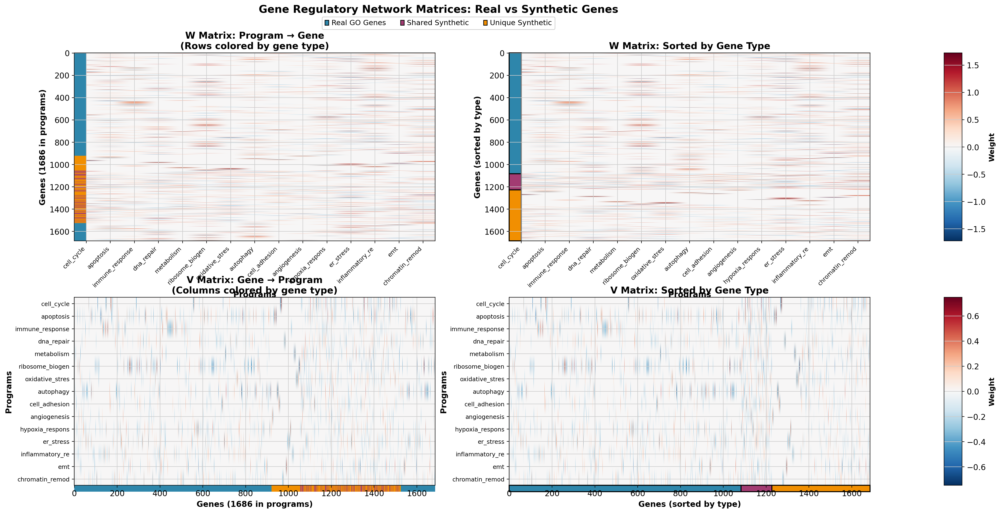

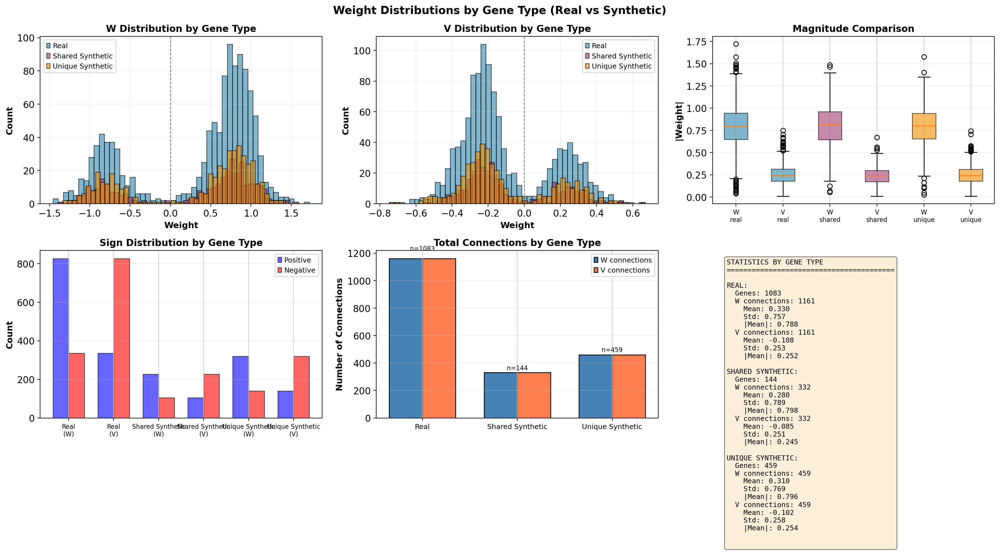

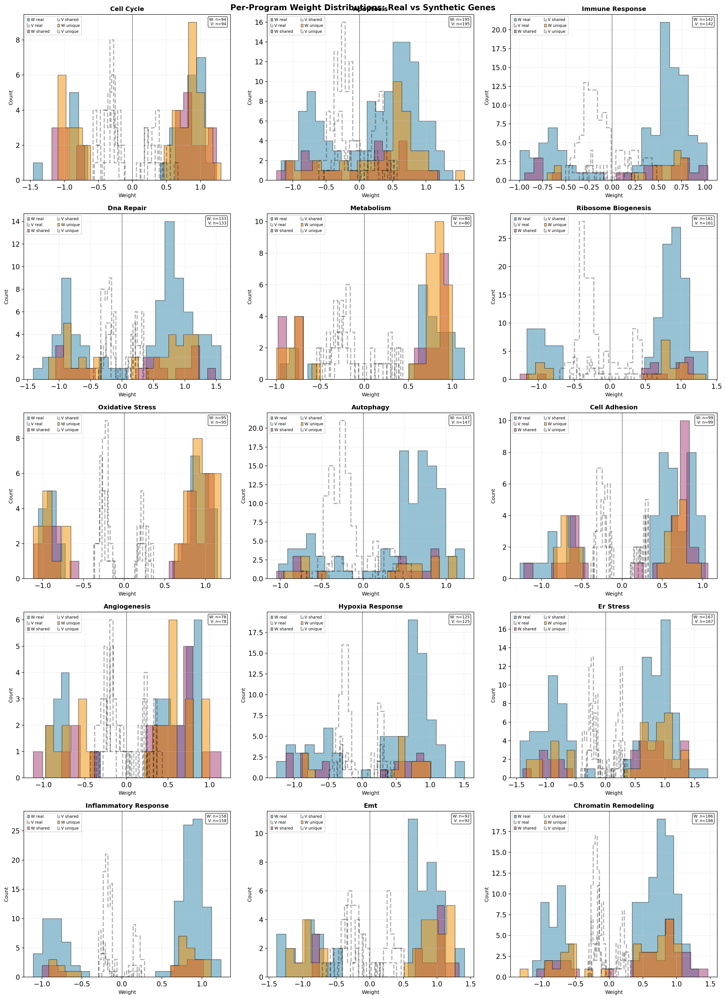

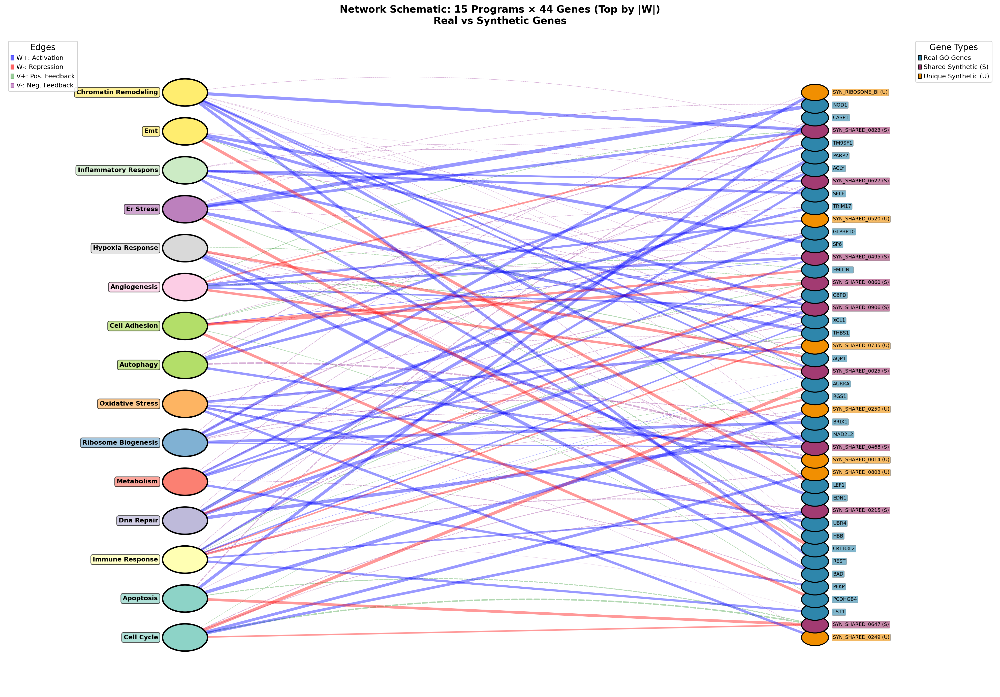

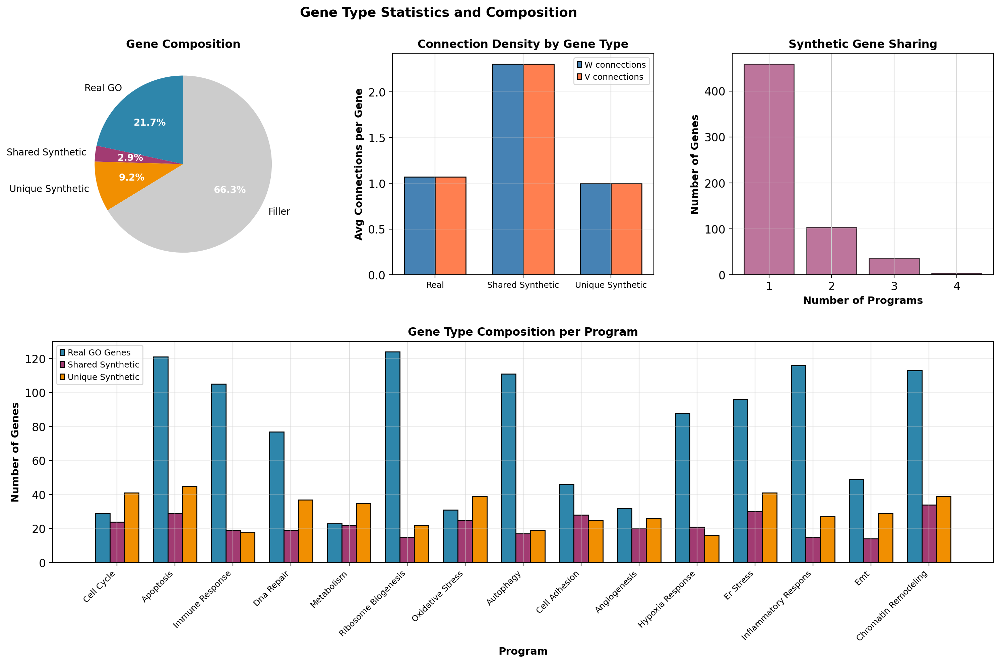

In [8]:
programs = go_gen.get_programs()
all_genes = go_gen.get_all_genes()

# Visualize everything
visualize_grn_complete(
    grn=grn,
    go_gen=go_gen
)